## House Price Prediction Model 

### Introduction 

##### The objective of this project is to develop a robust Multiple Linear Regression (MLR) model to estimate residential real estate prices. By analyzing a dataset of structural and geographic features, this project quantifies the drivers of property value to provide data-driven insights for stakeholders in the housing market.

### Business Objective


##### The primary goal of this project is to develop a quantitative valuation engine that reduces the subjectivity and time-intensity of traditional real estate appraisals.

##### **Precision Pricing**: To provide buyers and sellers with an evidence-based "Fair Market Value" to accelerate negotiations and minimize pricing errors.

##### **Investment Sensitivity Analysis**: To identify which specific features (e.g., an extra parking space vs. a reduction in city distance) yield the highest Return on Investment (ROI).

##### **Operational Scalability**: To create an automated pipeline capable of processing large volumes of property listings, enabling real-time market analysis for real estate firms or financial lenders.

### Dataset Architecture

##### The dataset is structured as a multivariate matrix where each row represents a unique property observation and each column represents a specific feature influencing the target variable.

##### **Core Components:**
##### **1) Target Variable:**

##### **- house_price:** The continuous numerical value representing the market price (Dependent Variable).

##### **2) Feature Vectors (Independent Variables):**

##### **- Physical Dimensions:** area_sqft (Continuous), bedrooms (Discrete).

##### **- Temporal Factor:** house_age_years (Continuous) – represents depreciation.

##### **- Utility Factor:** parking_spaces (Discrete) – measures functional capacity.

##### **- Locational Factor:** distance_city_center_km (Continuous) – measures urban accessibility.

### Data Flow Architecture:


##### **1) Ingestion Layer:** Raw data containing null values and unrefined market entries.

#####  **2) Refinement Layer: Imputation:** Statistical filling of missing entries using mean distribution.

##### **- Normalization:** Filtering of statistical noise via IQR-based outlier suppression.

##### **3) Analytical Layer:** Mapping of refined features to the price target via a Multiple Linear Regression hyperplane.


### Problem Statement


##### Valuing real estate is often subjective and prone to market volatility. Traditional valuation methods may overlook the nuanced relationships between physical attributes (like age and size) and locational factors (like proximity to urban centers). This project addresses the need for a predictive analytical tool that can objectively assess a property’s "Fair Market Value" based on historical trends.






### Importing Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [2]:
df = pd.read_excel(r"C:\Users\KOMAL\Downloads\multi lin 3.xlsx")

In [3]:
df.head(3)

,area_sqft,bedrooms,house_age_years,distance_city_center_km,parking_spaces,house_price
0,4429.591551,4.0,10.777783,15.124917,2.0,1.179111e+07
1,2572.058565,3.0,30.943699,10.004668,0.0,6.878326e+06
2,3192.233870,5.0,32.319484,18.223344,1.0,8.505669e+06


### Data Cleaning 

In [4]:
df.isnull().sum()

area_sqft                  40
bedrooms                   40
house_age_years            40
distance_city_center_km    40
parking_spaces             40
house_price                40
dtype: int64

In [5]:
df.describe()

,area_sqft,bedrooms,house_age_years,distance_city_center_km,parking_spaces,house_price
count,2960.000000,2960.000000,2960.000000,2960.000000,2960.000000,2.960000e+03
mean,2725.775774,3.494595,20.299450,15.626112,1.485811,7.363936e+06
std,1312.035808,1.701431,11.401330,8.467321,1.122657,3.408478e+06
min,400.380600,1.000000,0.000600,1.002283,0.000000,6.013680e+05
25%,1581.145544,2.000000,10.618682,8.316768,0.000000,4.489513e+06
50%,2734.997441,4.000000,20.745338,15.698336,1.000000,7.349067e+06
75%,3863.096841,5.000000,30.347975,23.097306,2.000000,1.014353e+07
max,4997.810198,6.000000,39.996938,29.997697,3.000000,2.452078e+07


In [17]:
from sklearn.impute import SimpleImputer

In [18]:
si = SimpleImputer(strategy='mean')

In [19]:
new = si.fit_transform(df[['area_sqft', 'bedrooms', 'house_age_years', 'distance_city_center_km',
       'parking_spaces', 'house_price']])

In [20]:
df[['area_sqft', 'bedrooms', 'house_age_years', 'distance_city_center_km','parking_spaces', 'house_price']] = pd.DataFrame(new)

In [21]:
df

,area_sqft,bedrooms,house_age_years,distance_city_center_km,parking_spaces,house_price
0,4429.591551,4.0,10.777783,15.124917,2.0,1.179111e+07
1,2572.058565,3.0,30.943699,10.004668,0.0,6.878326e+06
2,3192.233870,5.0,32.319484,18.223344,1.0,8.505669e+06
3,4404.744726,3.0,18.539963,12.178103,3.0,1.145814e+07
4,2544.915185,3.0,17.979532,21.452449,1.0,6.451837e+06
...,...,...,...,...,...,...
2995,2864.707463,3.0,25.142257,26.231444,3.0,7.784086e+06
2996,3616.471190,2.0,3.064035,20.294239,0.0,9.188897e+06
2997,3555.373133,2.0,35.124066,16.269641,3.0,9.171685e+06
2998,635.678615,1.0,16.351254,6.359724,1.0,1.890066e+06


In [22]:
df.isnull().sum()

area_sqft                  0
bedrooms                   0
house_age_years            0
distance_city_center_km    0
parking_spaces             0
house_price                0
dtype: int64

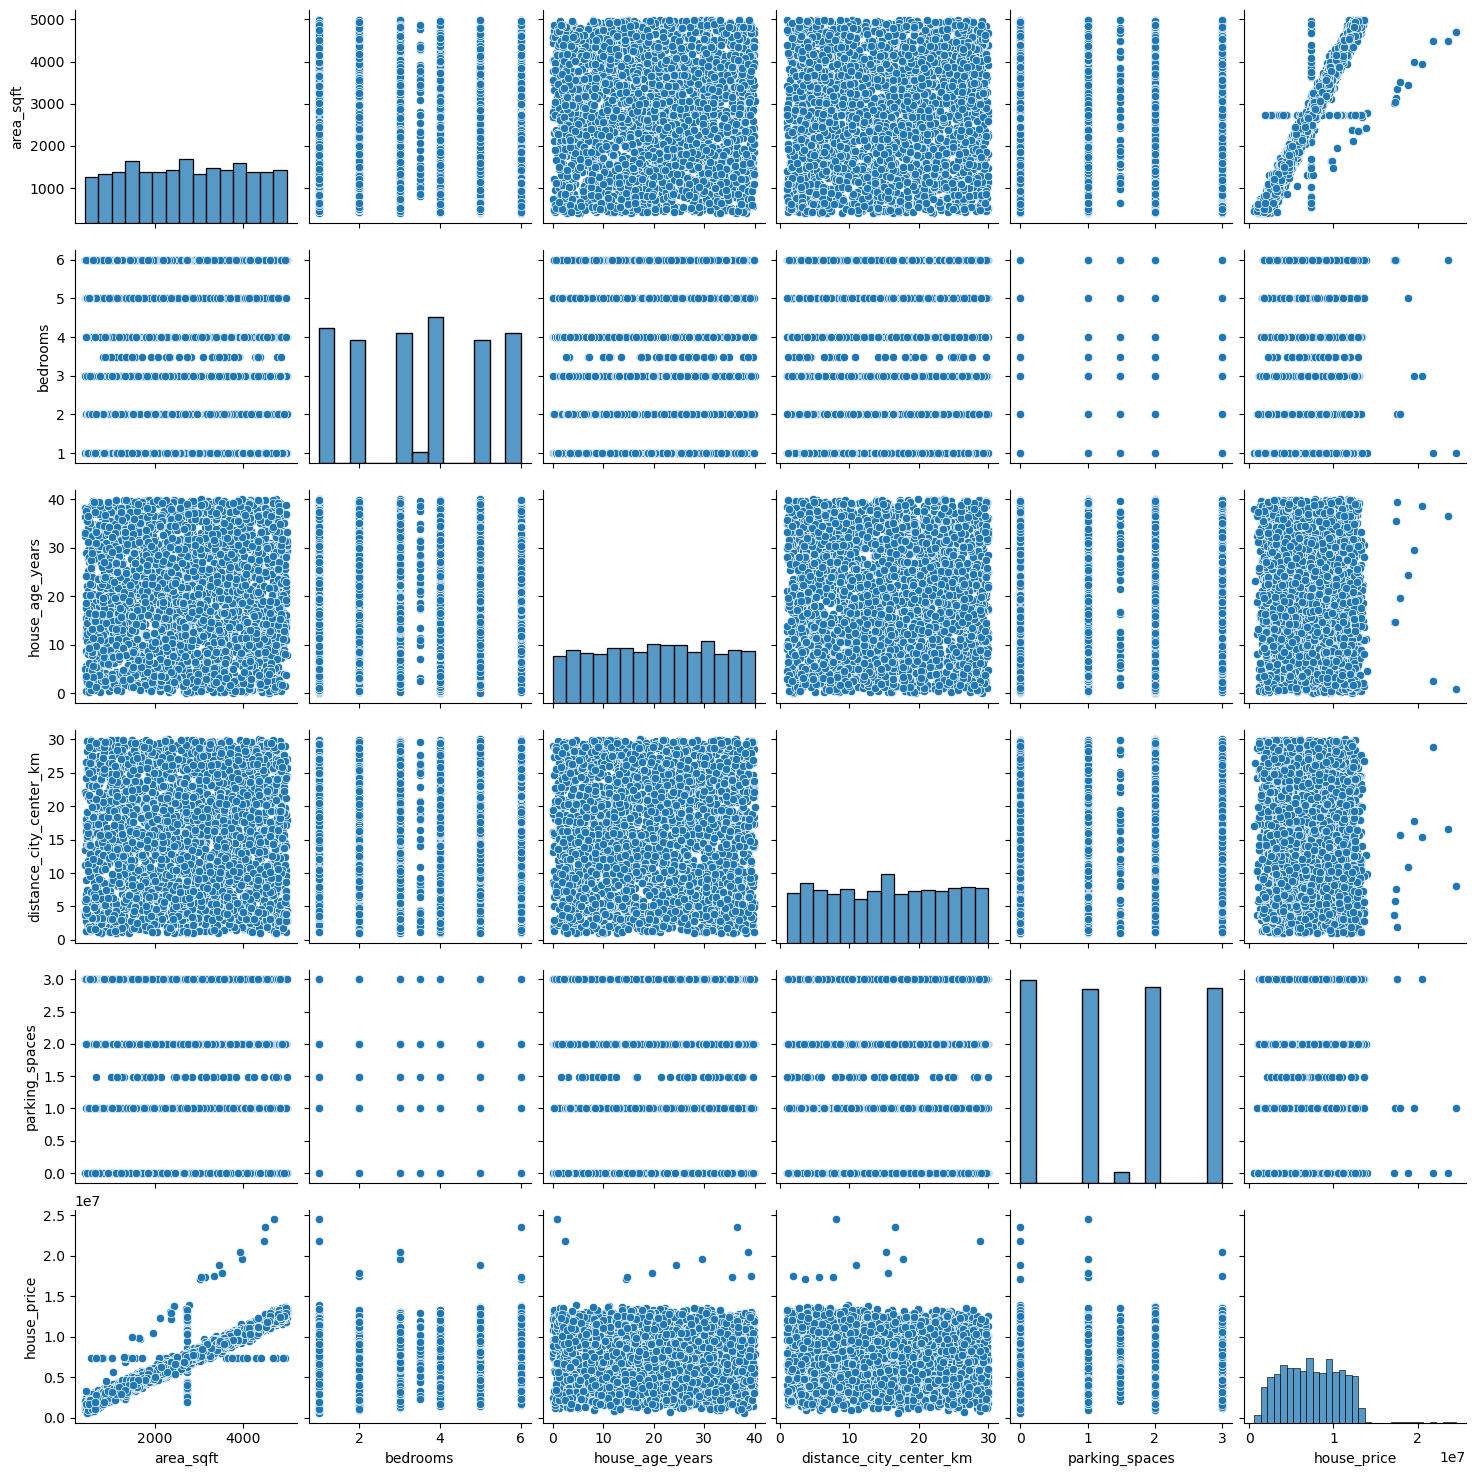

In [37]:
sns.pairplot(df)

### Removal of outliers using IQR method

In [23]:
q3 = df["house_price"].quantile(.75)
q1 = df['house_price'].quantile(.25)
q1,q3

(np.float64(4525202.809925253), np.float64(10095266.070359375))

In [24]:
iqr = q3-q1

In [25]:
iqr

np.float64(5570063.260434123)

In [26]:
max_range = q3+(1.5*iqr)
min_range = q1-(1.5*iqr)

In [27]:
max_range,min_range

(np.float64(18450360.96101056), np.float64(-3829892.0807259316))

In [28]:
new = df[(df['house_price'] <=max_range) &  (df['house_price'] >=min_range)]

In [29]:
x = new.iloc[:,:-1]
y = new['house_price']

### Model Training 

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train , X_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
lr = LinearRegression()

In [34]:
lr.fit(X_train, y_train)

LinearRegression()

In [35]:
lr.score(X_train,y_train)*100, lr.score(X_test,y_test)*100

(94.10116576516259, 94.97164289006004)

### Prediction of data 

In [39]:
ar = float(input("Enter the area sqft: "))
br = int(input("Enter the number of bedrooms :  "))
house_age = float(input("Enter the age of house : "))
dis = float(input("Enter the distance from the city : "))
park = int(input("Enter the parking space : "))

user_input = pd.DataFrame({'area_sqft' : [ar],
                            'bedrooms' : [br],
                            'house_age_years' : [house_age],
                            'distance_city_center_km' : [dis],
                            'parking_spaces' : [park]})
pr = lr.predict(user_input)

print("The predicted price of house is : ", pr[0].round(2))

Enter the area sqft:  2514
Enter the number of bedrooms :   3
Enter the age of house :  25.1
Enter the distance from the city :  12
Enter the parking space :  1


The predicted price of house is :  6702481.1
